VRAM을 충분히 확보하기 위하여 코랩의 L4 GPU를 사용하도록 권고합니다.

출처<br>
튜터리얼 https://www.datacamp.com/tutorial/fine-tuning-deepseek-r1-reasoning-model<br>
유튜브 https://youtu.be/qcNmOItRw4U?si=b6qvBLlif97uTcF-

참고 문헌<br>
unsloth 튜터리얼 https://www.datacamp.com/tutorial/unsloth-guide-optimize-and-speed-up-llm-fine-tuning<br>

## Credits

This notebook and this code is a fork of Abid Ali Awan's tutorial on [Fine-Tuning DeepSeek R1](https://www.datacamp.com/tutorial/fine-tuning-deepseek-r1-reasoning-model). Eternally grateful for his work with DataCamp and his contributions to the community.


## Which tools & packages will we be using today?

Packages we're going to be using throughout this walkthrough will be

- `unsloth`: Efficient fine-tuning and inference for LLMs — Specifically we will be using:
    - `FastLanguageModel` module to optimize inference & fine-tuning
    - `get_peft_model` to enable LoRa (Low-Rank Adaptation) fine-tuning
- `peft`: Supports LoRA-based fine-tuning for large models.
- Different Hugging Face modules:
    - `transformers` from HuggingFace to work with our fine-tuning data and handle different model tasks
    - `trl` Transformer Reinforcement Learning from HuggingFace which allows for supervised fine-tuning of the model — we will use the `SFFTrainer` wrapper
    - `datasets` to fetch reasoning datasets from the Hugging Face Hub
- `torch`: Deep learning framework used for training
- `wandb`: Provides access to weights and biases for tracking our fine-tuning experiment

## Before we get started — how to access the Hugging Face and Weights & Biases API

### Set GPU accelerator
We are using Kaggle Notebooks because we have access to free GPUs. To enable GPU access, press on Settings > Accelerator > GPU T4 x2

### How to access the Hugging Face API

1. Register to Huggin Face if you have not already
2. Go to [Hugging Face Tokens](https://huggingface.co/settings/tokens).
3. Click **"New Token"**.
4. Select **read/write** permissions if needed.
5. Copy your **API key**.

### Weights & Biases API key**
1. Sign up at [Weights & Biases](https://wandb.ai/site).
2. Go to [W&B Settings](https://wandb.ai/settings).
3. Copy your **API key** from the "API Keys" section.

### Add the API keys to Kaggle Notebooks
1. Press on Add-ons > Secrets
2. Add the API keys under `Hugging_Face_Token` and `wnb` respectively

You can now use this code to retrieve your API keys

```py
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
hugging_face_token = user_secrets.get_secret("Hugging_Face_Token")
wnb_token = user_secrets.get_secret("wnb")
```

## Install relevant packages

In [ ]:
%%capture
# installing from PyPI first may reduce the risk of dependency issues.
!pip install -q unsloth # install unsloth. automatically resolve dependencies
!pip install --force-reinstall --no-cache-dir --no-deps git+https://github.com/unslothai/unsloth.git # Also get the latest version Unsloth!

## Import all relevant packages throughout this walkthrough

In [ ]:
!pip install -q datasets trl

In [ ]:
# Modules for fine-tuning
from unsloth import FastLanguageModel
import torch # Import PyTorch
from trl import SFTTrainer # Trainer for supervised fine-tuning (SFT)
from unsloth import is_bfloat16_supported # Checks if the hardware supports bfloat16 precision
# Hugging Face modules
from huggingface_hub import login # Lets you login to API
from transformers import TrainingArguments # Defines training hyperparameters
from datasets import load_dataset # Lets you load fine-tuning datasets
# Import weights and biases
import wandb

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [ ]:
!ls -lh outputs


ls: cannot access 'outputs': No such file or directory


## Create API keys and login to Hugging Face and Weights and Biases

HF Token
<details>
</details>

In [ ]:
import os
hugging_face_token = "" 
wnb_token = ""

In [ ]:
# Initialize Hugging Face & WnB tokens
# # Login to Hugging Face
login(hugging_face_token) # from huggingface_hub import login

# # Login to WnB
wandb.login(key=wnb_token) # import wandb
run = wandb.init(
project='Fine-tune-DeepSeek-R1-Distill-Llama-8B on Medical COT Dataset_YouTube Walkthrough_v2',
job_type="training",
anonymous="allow"
)

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: 20221335 (20221335-sungshin-women-s-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: Detected [huggingface_hub.inference, openai] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai/


## Loading DeepSeek R1 and the Tokenizer

**What are we doing in this step?**

In this step, we **load the DeepSeek R1 model and its tokenizer** using `FastLanguageModel.from_pretrained()`. We also **configure key parameters** for efficient inference and fine-tuning. We will be using a distilled 8B version of R1 for faster computation.  

**Key parameters explained**
```py
max_seq_length = 2048  # Define the maximum sequence length a model can handle (i.e., number of tokens per input)
dtype = None  # Default data type (usually auto-detected)
load_in_4bit = True  # Enables 4-bit quantization – a memory-saving optimization
```

**Intuition behind 4-bit quantization**

Imagine compressing a **high-resolution image** to a smaller size—**it takes up less space but still looks good enough**. Similarly, **4-bit quantization reduces the precision of model weights**, making the model **smaller and faster while keeping most of its accuracy**. Instead of storing precise **32-bit or 16-bit numbers**, we compress them into **4-bit values**. This allows **large language models to run efficiently on consumer GPUs** without needing massive amounts of memory.

In [ ]:
# Set parameters
max_seq_length = 2048 # Define the maximum sequence length a model can handle (i.e. how many tokens can be processed at once)
dtype = None # Set to default
load_in_4bit = True # Enables 4 bit quantization — a memory saving optimization

# Load the DeepSeek R1 model and tokenizer using unsloth — imported using: from unsloth import FastLanguageModel
model, tokenizer = FastLanguageModel.from_pretrained(
    # 사전학습된 언어모델을 선택하여 해당 라인을 uncomment하고 Load the pre-trained DeepSeek R1 model (8B parameter version)
    model_name="unsloth/DeepSeek-R1-Distill-Qwen-7B",
    # model_name="unsloth/DeepSeek-R1-Distill-Qwen-7B",
    max_seq_length=max_seq_length, # Ensure the model can process up to 2048 tokens at once
    dtype=dtype, # Use the default data type (e.g., FP16 or BF16 depending on hardware support)
    load_in_4bit=load_in_4bit, # Load the model in 4-bit quantization to save memory
    #token=hugging_face_token, # Use hugging face token
    token=os.environ.get("hugging_face_token"), # Use hugging face token
)

==((====))==  Unsloth 2025.9.11: Fast Qwen2 patching. Transformers: 4.56.1.
   \\   /|    NVIDIA L4. Num GPUs = 1. Max memory: 22.161 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu126. CUDA: 8.9. CUDA Toolkit: 12.6. Triton: 3.4.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.32.post2. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/3.52G [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.97G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/236 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

Qwen 7B 모델을 L4에 로드한 경우<br>
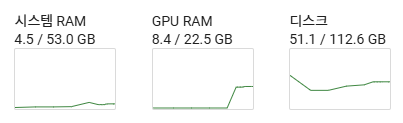

## Testing DeepSeek R1 on a medical use-case before fine-tuning


### Defining a system prompt
To create a prompt style for the model, we will define a system prompt and include placeholders for the question and response generation. The prompt will guide the model to think step-by-step and provide a logical, accurate response.

In [ ]:
# Define a system prompt under prompt_style
prompt_style = """아래는 특정 작업에 대한 지침과 함께, 추가적인 맥락을 제공하는 입력이 주어져 있습니다.
요청에 적절히 응답하는 답변을 작성하세요.
답변을 작성하기 전에 질문을 신중히 분석하고, 단계적인 사고 과정을 통해 논리적이고 정확한 결론에 도달하세요.

### 지침:
당신은 임상 추론, 진단, 치료 계획에 대해 고도의 전문 지식을 갖춘 의료 전문가입니다.
다음 의학 질문에 대해 **한국어로만** 답변해 주세요.

### 질문:
{}

### 응답:
<think>{}"""


### Running inference on the model

In this step, we **test the DeepSeek R1 model** by providing a **medical question** and generating a response.  
The process involves the following steps:

1. **Define a test question** related to a medical case.
2. **Format the question using the structured prompt (`prompt_style`)** to ensure the model follows a logical reasoning process.
3. **Tokenize the input and move it to the GPU (`cuda`)** for faster inference.
4. **Generate a response using the model**, specifying key parameters like `max_new_tokens=1200` (limits response length).
5. **Decode the output tokens back into text** to obtain the final readable answer.

In [ ]:
# Creating a test medical question for inference
question = """61세 여성이 기침이나 재채기 같은 활동 중에 발생하는 오랜 요실금 병력이 있으나,
밤에는 누출이 없습니다. 부인과 검사와 Q-tip 테스트를 시행하였습니다.
이러한 소견에 근거할 때, 방광내압검사는 잔뇨량과 배뇨근 수축에 대해 어떤 결과를 보여줄 가능성이 높을까요?"""

# Enable optimized inference mode for Unsloth models (improves speed and efficiency)
FastLanguageModel.for_inference(model)  # Unsloth has 2x faster inference!

# Format the question using the structured prompt (`prompt_style`) and tokenize it
inputs = tokenizer([prompt_style.format(question, "")], return_tensors="pt").to("cuda")  # Convert input to PyTorch tensor & move to GPU

# Generate a response using the model
outputs = model.generate(
    input_ids=inputs.input_ids, # Tokenized input question
    attention_mask=inputs.attention_mask, # Attention mask to handle padding
    max_new_tokens=1200, # Limit response length to 1200 tokens (to prevent excessive output)
    use_cache=True, # Enable caching for faster inference
)

# Decode the generated output tokens into human-readable text
response = tokenizer.batch_decode(outputs)

# Extract and print only the relevant response part (after "### Response:")
print(response[0].split("### 응답:")[1])


<think>
Alright, so I have a 61-year-old woman presenting with chronic dysphoria, specifically during physical activities but not at night. She's also been diagnosed with a gynecomastia, which is a common condition related to the adrenals. The doctor is considering a diagnosis of residual hydramnium syndrome, which is associated with an accumulative hydroxyureauria and can lead to a build-up of fluid in the brain, causing headaches and other symptoms. 

She's had a urinalysis and Q-tip test. The urinalysis might show proteinuria, which is a sign of residual hydramnium syndrome. The Q-tip test is used to detect glucose and ketones in urine, which can indicate ketonuria, a sign of residual hydramnium syndrome. 

The doctor is considering whether to perform an orthopnea (standing orthopnea) test to rule out residual hydramnium syndrome. If the results are positive, it would suggest the presence of residual hydramnium syndrome and possibly a build-up of fluid in the brain. If negative, th

>**Before starting fine-tuning — why are we fine-tuning in the first place?**
>
> Even without fine-tuning, our model successfully generated a chain of thought and provided reasoning before delivering the final answer. The reasoning process is encapsulated within the `<think>` `</think>` tags. So, why do we still need fine-tuning? The reasoning process, while detailed, was long-winded and not concise. Additionally, we want the final answer to be consistent in a certain style.



## Fine-tuning step by step

### Step 1 — Update the system prompt
We will slightly change the prompt style for processing the dataset by adding the third placeholder for the complex chain of thought column. `</think>`

In [ ]:
# Updated training prompt style to add </think> tag
train_prompt_style = """아래는 특정 작업에 대한 지침과 함께, 추가적인 맥락을 제공하는 입력이 주어져 있습니다.
요청에 적절히 응답하는 답변을 작성하세요.
답변을 작성하기 전에 질문을 신중히 분석하고, 단계적인 사고 과정을 통해 논리적이고 정확한 결론에 도달하세요.

### 지침:
당신은 임상 추론, 진단, 치료 계획에 대해 고도의 전문 지식을 갖춘 의료 전문가입니다.
다음 의학 질문에 대해 **한국어로만** 답변해 주세요.

### 질문:
{}

### 응답:
<think>
{}
</think>
{}"""


### Step 2 — Download the fine-tuning dataset and format it for fine-tuning

We will use the Medical O1 Reasoninng SFT found here on [Hugging Face](https://huggingface.co/datasets/FreedomIntelligence/medical-o1-reasoning-SFT). From the authors: This dataset is used to fine-tune HuatuoGPT-o1, a medical LLM designed for advanced medical reasoning. This dataset is constructed using GPT-4o, which searches for solutions to verifiable medical problems and validates them through a medical verifier.

In [ ]:
# Download the dataset using Hugging Face — function imported using from datasets import load_dataset
dataset = load_dataset("FreedomIntelligence/medical-o1-reasoning-SFT","en", split = "train[0:500]",trust_remote_code=True) # Keep only first 500 rows
dataset

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'FreedomIntelligence/medical-o1-reasoning-SFT' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'FreedomIntelligence/medical-o1-reasoning-SFT' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


README.md: 0.00B [00:00, ?B/s]

medical_o1_sft.json:   0%|          | 0.00/58.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/19704 [00:00<?, ? examples/s]

Dataset({
    features: ['Question', 'Complex_CoT', 'Response'],
    num_rows: 500
})

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from datasets import Dataset
import json
import re

# 1. 병합된 JSON 경로 지정
json_path = "/content/drive/MyDrive/Colab Notebooks/medical_translated_0000_19700.json"

# 2. JSON 로드
with open(json_path, "r", encoding="utf-8") as f:
    data = json.load(f)

# 3. 한자(중국어)가 포함되었는지 확인하는 함수
def contains_chinese(text):
    return bool(re.search(r'[\u4e00-\u9fff]', text))

# 4. 유효 항목만 골라내고, 중국어 제거
cleaned_data = []
skipped_chinese = 0
skipped_incomplete = 0

for item in data:
    if all(k in item for k in ["Question_ko", "Complex_CoT_ko", "Response_ko"]):
        q, c, r = item["Question_ko"], item["Complex_CoT_ko"], item["Response_ko"]
    elif all(k in item for k in ["Question", "Complex_CoT", "Response"]):
        q, c, r = item["Question"], item["Complex_CoT"], item["Response"]
    else:
        skipped_incomplete += 1
        continue

    # 한자 포함 여부 확인
    if contains_chinese(q) or contains_chinese(c) or contains_chinese(r):
        skipped_chinese += 1
        continue

    cleaned_data.append({
        "Question": q,
        "Complex_CoT": c,
        "Response": r
    })

print(f"✅ 최종 유효한 항목 수: {len(cleaned_data)}")
print(f"🚫 제거된 중국어 포함 항목 수: {skipped_chinese}")
print(f"🚫 키 누락 등으로 제외된 항목 수: {skipped_incomplete}")

# 5. 🤗 Hugging Face Dataset으로 변환
dataset = Dataset.from_list(cleaned_data)


✅ 최종 유효한 항목 수: 18966
🚫 제거된 중국어 포함 항목 수: 192
🚫 키 누락 등으로 제외된 항목 수: 0


In [ ]:
# Show an entry from the dataset
dataset[1]

{'Question': '33세 여성이 드라이버로 가슴을 찔린 지 15분 후 응급실로 후송되었습니다.  맥박 110/분, 호흡 22/분, 혈압 90/65 mmHg의 활력징후와 좌측 겨드랑이 중앙선 8번째 갈비뼈 상연에 깊이 5cm의 자상이 있는 것을 고려할 때, 그녀의 가슴에서 가장 손상되었을 가능성이 높은 해부학적 구조는 무엇입니까?',
 'Complex_CoT': '자, 여기서 무슨 일인지 알아봅시다. 한 여성이 드라이버에 찔린 상처를 입고 왔습니다.  흉부, 왼쪽 8번째 갈비뼈 상연, 겨드랑이 중간선(midaxillary line) 부근입니다.  일단 생각해보면, 폐가 있는 곳과 매우 가깝죠?\n\n먼저 위치부터 이야기해 봅시다.  왼쪽 몸통에 위치하고 있으며, 8번째 갈비뼈 위쪽, 그 부위에는 좌측 폐 하엽과 횡경막 등 중요한 장기들이 많이 있습니다. 드라이버가 얼마나 깊이 들어갔는지 고려하면 횡경막도 포함될 가능성이 있습니다.\n\n상처 깊이는 5cm입니다.  꽤 깊네요. 폐 조직이나 횡경막까지 도달했을 가능성이 분명히 있습니다. 겨드랑이 중간선(midaxillary) 부위라는 점을 고려하면, 좌측 폐 하엽이 있는 영역입니다. 횡경막과 일부 겹칠 가능성도 있지만, 폐가 더 유력해 보입니다.\n\n이제 활력징후가 문제입니다. 심박수가 높고 혈압이 낮습니다. 심각하네요.  제 생각에는 이런 활력징후는 pneumothorax 또는 hemothorax를 의미할 수 있습니다. 폐가 손상되면 두 가지 모두 발생할 수 있으며, 환자는 분명 고통스러울 것이므로 혈압을 떨어뜨리고 심박수를 치솟게 할 수 있습니다.\n\n그러니까, 종합해 보면 가장 의심되는 것은 좌측 폐 하엽입니다. 상처의 깊이와 환자의 상태가 이를 뒷받침합니다.  그리고 이것은 pneumothorax 또는 흉부에 출혈—호흡과 순환에 심각한 문제를 일으킬 수 있는 것들—과 일치합니다.\n\n좋아요, 이를 고려해 볼 때, 가장 손상될 가능성이 높은 것은 폐인 것 같습니다. 상처 위치, 증상, 그리고 전체

>**Next step is to structure the fine-tuning dataset according to train prompt style—why?**
>
> - Each question is paired with chain-of-thought reasoning and the final response.
> - Ensures every training example follows a consistent pattern.
> - Prevents the model from continuing beyond the expected response lengt by adding the EOS token.

In [ ]:
# We need to format the dataset to fit our prompt training style
EOS_TOKEN = tokenizer.eos_token  # Define EOS_TOKEN which the model when to stop generating text during training
EOS_TOKEN

'<｜end▁of▁sentence｜>'

In [ ]:
# Define formatting prompt function
def formatting_prompts_func(examples):  # Takes a batch of dataset examples as input
    inputs = examples["Question"]       # Extracts the medical question from the dataset
    cots = examples["Complex_CoT"]      # Extracts the chain-of-thought reasoning (logical step-by-step explanation)
    outputs = examples["Response"]      # Extracts the final model-generated response (answer)

    texts = []  # Initializes an empty list to store the formatted prompts

    # Iterate over the dataset, formatting each question, reasoning step, and response
    for input, cot, output in zip(inputs, cots, outputs):
        text = train_prompt_style.format(input, cot, output) + EOS_TOKEN  # Insert values into prompt template & append EOS token
        texts.append(text)  # Add the formatted text to the list

    return {
        "text": texts,  # Return the newly formatted dataset with a "text" column containing structured prompts
    }

In [ ]:
# Update dataset formatting
dataset_finetune = dataset.map(formatting_prompts_func, batched = True)
dataset_finetune["text"][0]

Map:   0%|          | 0/18966 [00:00<?, ? examples/s]

"아래는 특정 작업에 대한 지침과 함께, 추가적인 맥락을 제공하는 입력이 주어져 있습니다.\n요청에 적절히 응답하는 답변을 작성하세요.\n답변을 작성하기 전에 질문을 신중히 분석하고, 단계적인 사고 과정을 통해 논리적이고 정확한 결론에 도달하세요.\n\n### 지침:\n당신은 임상 추론, 진단, 치료 계획에 대해 고도의 전문 지식을 갖춘 의료 전문가입니다.\n다음 의학 질문에 대해 **한국어로만** 답변해 주세요.\n\n### 질문:\n왼쪽 팔과 다리의 갑작스러운 약화(sudden weakness), 최근 장거리 여행(recent long-distance travel), 그리고 부어오르고 압통이 있는 오른쪽 아랫다리(swollen and tender right lower leg) 증상을 고려할 때, 이러한 소견을 설명할 수 있는 가장 가능성 높은 특정 심장 이상(cardiac abnormality)은 추가 검사(further evaluation)에서 무엇일까요?\n\n### 응답:\n<think>\nOkay, let's see what's going on here.  환자의 왼쪽 팔과 다리에 갑작스러운 weakness가 나타났습니다 - 이건 신경계 관련 문제, 어쩌면 stroke?을 시사합니다.\n\n하지만, 그게 다가 아닙니다. 오른쪽 아래 다리가 부어오르고 tender합니다. 이건 특히 장시간 비행이나 오랫동안 앉아 있은 후에, deep vein thrombosis를 강하게 의심하게 만드는 증상입니다.\n\n그러니 이제 생각해 봐야 합니다. 다리의 clot이 어떻게 weakness나 stroke 증상 같은 문제를 일으킬 수 있을까요?\n\n아, 맞다! paradoxical embolism이라는 것이 있습니다. 심장에 어떤 종류의 short circuit, 예를 들어 있어서는 안 될 구멍이 있을 경우 발생할 수 있습니다.\n\n정리해 봅시다: 다리의 혈전이 어떻게든 심장의 왼쪽으로 이동하면, 뇌로 이동하여 혈류를 차단하고 그 갑작스러운 weakness를 일으

### Step 3 — Setting up the model using LoRA

**An intuitive explanation of LoRA**

Large language models (LLMs) have **millions or even billions of weights** that determine how they process and generate text. When fine-tuning a model, we usually update all these weights, which **requires massive computational resources and memory**.

LoRA (**Low-Rank Adaptation**) allows to fine-tune efficiently by:

- Instead of modifying all weights, **LoRA adds small, trainable adapters** to specific layers.  
- These adapters **capture task-specific knowledge** while leaving the original model unchanged.  
- This reduces the number of trainable parameters **by more than 90%**, making fine-tuning **faster and more memory-efficient**.  

Think of an LLM as a **complex factory**. Instead of rebuilding the entire factory to produce a new product, LoRA **adds small, specialized tools** to existing machines. This allows the factory to adapt quickly **without disrupting its core structure**.

For a more technical explanation, check out this tutorial by [Sebastian Raschka](https://www.youtube.com/watch?v=rgmJep4Sb4&t).

Below, we will use the `get_peft_model()` function which stands for Parameter-Efficient Fine-Tuning — this function wraps the base model (`model`) with LoRA modifications, ensuring that only specific parameters are trained.

In [ ]:
# Apply LoRA (Low-Rank Adaptation) fine-tuning to the model
model_lora = FastLanguageModel.get_peft_model(
    model,
    r=8,  # LoRA rank: Determines the size of the trainable adapters (higher = more parameters, lower = more efficiency)
    target_modules=[  # List of transformer layers where LoRA adapters will be applied
        "q_proj",   # Query projection in the self-attention mechanism
        "k_proj",   # Key projection in the self-attention mechanism
        "v_proj",   # Value projection in the self-attention mechanism
        "o_proj",   # Output projection from the attention layer
        "gate_proj",  # Used in feed-forward layers (MLP)
        "up_proj",    # Part of the transformer’s feed-forward network (FFN)
        "down_proj",  # Another part of the transformer’s FFN
    ],
    lora_alpha=8,  # Scaling factor for LoRA updates (higher values allow more influence from LoRA layers)
    lora_dropout=0,  # Dropout rate for LoRA layers (0 means no dropout, full retention of information)
    bias="none",  # Specifies whether LoRA layers should learn bias terms (setting to "none" saves memory)
    use_gradient_checkpointing="unsloth",  # Saves memory by recomputing activations instead of storing them (recommended for long-context fine-tuning)
    random_state=3407,  # Sets a seed for reproducibility, ensuring the same fine-tuning behavior across runs
    use_rslora=False,  # Whether to use Rank-Stabilized LoRA (disabled here, meaning fixed-rank LoRA is used)
    loftq_config=None,  # Low-bit Fine-Tuning Quantization (LoFTQ) is disabled in this configuration
)

Unsloth 2025.9.11 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


In [ ]:
import types

In [ ]:
# Define a new `for_training` method that avoids the problematic part
def for_training_patched(self, use_gradient_checkpointing=True):
    """Sets the model to training mode and optionally enables gradient checkpointing."""
    self.train()  # enable training mode

# Dynamically add the new `for_training` method to the `model_lora` object
model_lora.for_training = types.MethodType(for_training_patched, model_lora)

Now, we initialize `SFTTrainer`, a supervised fine-tuning trainer from `trl` (Transformer Reinforcement Learning), to fine-tune our model efficiently on a dataset.

In [ ]:
output_dir = "/content/drive/MyDrive/deepseek_outputs"
# Initialize the fine-tuning trainer — Imported using from trl import SFTTrainer
trainer = SFTTrainer(
    model=model_lora,  # The model to be fine-tuned
    tokenizer=tokenizer,  # Tokenizer to process text inputs
    train_dataset=dataset_finetune,  # Dataset used for training
    dataset_text_field="text",  # Specifies which field in the dataset contains training text
    max_seq_length=max_seq_length,  # Defines the maximum sequence length for inputs
    dataset_num_proc=2,  # Uses 2 CPU threads to speed up data preprocessing

    # Define training arguments
    args=TrainingArguments(
        per_device_train_batch_size=1,  # Number of examples processed per device (GPU) at a time
        gradient_accumulation_steps=8,  # Accumulate gradients over 4 steps before updating weights
        num_train_epochs=3, # Full fine-tuning run
        warmup_steps=5,  # Gradually increases learning rate for the first 5 steps
         # Limits training to 60 steps (useful for debugging; increase for full fine-tuning)
        learning_rate=2e-4,  # Learning rate for weight updates (tuned for LoRA fine-tuning)
        fp16=not is_bfloat16_supported(),  # Use FP16 (if BF16 is not supported) to speed up training
        bf16=is_bfloat16_supported(),  # Use BF16 if supported (better numerical stability on newer GPUs)
        logging_steps=10,  # Logs training progress every 10 steps
        optim="adamw_8bit",  # Uses memory-efficient AdamW optimizer in 8-bit mode
        weight_decay=0.01,  # Regularization to prevent overfitting
        lr_scheduler_type="linear",  # Uses a linear learning rate schedule
        seed=3407,  # Sets a fixed seed for reproducibility
        output_dir=output_dir,
        report_to='none',
        save_strategy="steps",
        save_steps=500,                  # 500 step마다 checkpoint 저장
        save_total_limit=3,              # 최근 3개만 유지 (이전 것은 자동 삭제)
    ),
)


Unsloth: Tokenizing ["text"] (num_proc=16):   0%|          | 0/18966 [00:00<?, ? examples/s]

## Step 4 — Model training!
- colab T4에서 500개 트레이닝하는데 20분 가량 소요
This should take around 30 to 40 minutes — we can then check out our training results on Weights and Biases

In [ ]:
from transformers.trainer_utils import get_last_checkpoint
last_checkpoint = get_last_checkpoint(output_dir)
if last_checkpoint is None:
    print(f"[INFO] No checkpoint found. Training will start from scratch.")
else:
    print(f"[INFO] Found checkpoint {last_checkpoint}. Resuming training from it.")

[INFO] Found checkpoint /content/drive/MyDrive/deepseek_outputs/checkpoint-7000. Resuming training from it.


In [ ]:
# Start the fine-tuning process
trainer_stats = trainer.train(resume_from_checkpoint=False)

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 18,966 | Num Epochs = 3 | Total steps = 7,113
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 20,185,088 of 7,635,801,600 (0.26% trained)


Step,Training Loss
10,3.152900
20,2.624700
30,2.256300
40,2.051000
50,1.918500
60,1.905100
70,1.862300
80,1.799500
90,1.773600
100,1.678300


Step,Training Loss
10,3.152900
20,2.624700
30,2.256300
40,2.051000
50,1.918500
60,1.905100
70,1.862300
80,1.799500
90,1.773600
100,1.678300


In [ ]:
trainer_stats = trainer.train(resume_from_checkpoint=last_checkpoint)

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 18,966 | Num Epochs = 3 | Total steps = 7,113
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 20,185,088 of 7,635,801,600 (0.26% trained)


Step,Training Loss
4010,1.167500
4020,1.164800
4030,1.197800
4040,1.209700
4050,1.135500
4060,1.185700
4070,1.143900
4080,1.189000
4090,1.180800
4100,1.188700


In [ ]:
trainer_stats = trainer.train(resume_from_checkpoint=last_checkpoint)

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 18,966 | Num Epochs = 3 | Total steps = 7,113
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 20,185,088 of 7,635,801,600 (0.26% trained)


Step,Training Loss
7010,1.100800
7020,1.038000
7030,1.075700
7040,1.084400
7050,1.052200
7060,1.087900
7070,1.052800
7080,1.049100
7090,1.063500
7100,1.090300


unsloth로 라마3 8B 파인튜닝한 모델의 T4 VRAM 메모리 사용량<br>
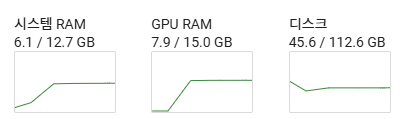

unsloth로 Qwn 7BB 파인튜닝한 모델의 L4 VRAM 메모리 사용량<br>
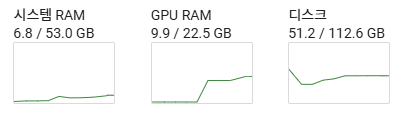

In [ ]:
trainer_stats

TrainOutput(global_step=7112, training_loss=0.016973028602696644, metrics={'train_runtime': 707.2588, 'train_samples_per_second': 80.449, 'train_steps_per_second': 10.057, 'total_flos': 2.297828445816573e+18, 'train_loss': 0.016973028602696644, 'epoch': 2.999683644416324})

In [ ]:
model_lora

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Qwen2ForCausalLM(
      (model): Qwen2Model(
        (embed_tokens): Embedding(152064, 3584, padding_idx=151654)
        (layers): ModuleList(
          (0-3): 4 x Qwen2DecoderLayer(
            (self_attn): Qwen2Attention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=3584, out_features=3584, bias=True)
                (lora_dropout): ModuleDict(
                  (default): Identity()
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=3584, out_features=8, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=8, out_features=3584, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): lora.Linear(
   

In [ ]:
model_lora.push_to_hub("nanyaas/deepseek-r1-medicalQA-Qwen_7B_dev") # Online saving
tokenizer.push_to_hub("nanyaas/deepseek-r1-medicalQA-Qwen_7B_dev") # Online saving

README.md:   0%|          | 0.00/624 [00:00<?, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors:   0%|          | 45.5kB / 80.8MB            

Saved model to https://huggingface.co/nanyaas/deepseek-r1-medicalQA-Qwen_7B_dev


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mpmetaqjrm/tokenizer.json: 100%|##########| 11.4MB / 11.4MB            

In [ ]:
new_model_name = "nanyaas/deepseek-r1-medicalQA-Qwen_7B_dev"
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = new_model_name, # YOUR MODEL YOU USED FOR TRAINING
    max_seq_length = 2048,
    dtype = None,
    load_in_4bit = True,
)
FastLanguageModel.for_inference(model);

==((====))==  Unsloth 2025.9.11: Fast Qwen2 patching. Transformers: 4.56.1.
   \\   /|    NVIDIA L4. Num GPUs = 1. Max memory: 22.161 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu126. CUDA: 8.9. CUDA Toolkit: 12.6. Triton: 3.4.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.32.post2. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

adapter_model.safetensors:   0%|          | 0.00/80.8M [00:00<?, ?B/s]

In [ ]:
model_lora.push_to_hub_gguf(new_model_name, tokenizer, quantization_method = "q4_k_m")

Unsloth: ##### The current model auto adds a BOS token.
Unsloth: ##### Your chat template has a BOS token. We shall remove it temporarily.
Unsloth: Kaggle/Colab has limited disk space. We need to delete the downloaded
model which will save 4-16GB of disk space, allowing you to save on Kaggle/Colab.
Unsloth: Will remove a cached repo with size 8.5G


Unsloth: Merging 4bit and LoRA weights to 16bit...
Unsloth: Will use up to 32.16 out of 52.96 RAM for saving.
Unsloth: Saving model... This might take 5 minutes ...


 18%|█▊        | 5/28 [00:00<00:01, 14.17it/s]
We will save to Disk and not RAM now.
100%|██████████| 28/28 [00:36<00:00,  1.31s/it]


Unsloth: Saving tokenizer... Done.
Done.


Unsloth: Converting qwen2 model. Can use fast conversion = False.


==((====))==  Unsloth: Conversion from QLoRA to GGUF information
   \\   /|    [0] Installing llama.cpp might take 3 minutes.
O^O/ \_/ \    [1] Converting HF to GGUF 16bits might take 3 minutes.
\        /    [2] Converting GGUF 16bits to ['q4_k_m'] might take 10 minutes each.
 "-____-"     In total, you will have to wait at least 16 minutes.

Unsloth: Installing llama.cpp. This might take 3 minutes...
Unsloth: CMAKE detected. Finalizing some steps for installation.
Unsloth: [1] Converting model at nanyaas/deepseek-r1-medicalQA-Qwen_7B_dev into bf16 GGUF format.
The output location will be /content/nanyaas/deepseek-r1-medicalQA-Qwen_7B_dev/unsloth.BF16.gguf
This might take 3 minutes...
INFO:hf-to-gguf:Loading model: deepseek-r1-medicalQA-Qwen_7B_dev
INFO:hf-to-gguf:Model architecture: Qwen2ForCausalLM
INFO:gguf.gguf_writer:gguf: This GGUF file is for Little Endian only
INFO:hf-to-gguf:Exporting model...
INFO:hf-to-gguf:gguf: loading model weight map from 'model.safetensors.index.json'


RuntimeError: Unsloth: Quantization failed for /content/nanyaas/deepseek-r1-medicalQA-Qwen_7B_dev/unsloth.BF16.gguf
You might have to compile llama.cpp yourself, then run this again.
You do not need to close this Python program. Run the following commands in a new terminal:
You must run this in the same folder as you're saving your model.
git clone --recursive https://github.com/ggerganov/llama.cpp
cd llama.cpp && make clean && make all -j
Once that's done, redo the quantization.

main: quantize time = 1023256.77 ms
main:    total time = 1023256.77 ms
Unsloth: Conversion completed! Output location: /content/boazchung/deepseek-r1-medicalQA/unsloth.Q4_K_M.gguf
Unsloth: Uploading GGUF to Huggingface Hub...
100%
 1/1 [00:45<00:00, 45.65s/it]
unsloth.Q4_K_M.gguf:
 4.93G/? [00:45<00:00, 774MB/s]
Unsloth: ##### The current model auto adds a BOS token.
Unsloth: ##### We removed it in GGUF's chat template for you.
Saved GGUF to https://huggingface.co/boazchung/deepseek-r1-medicalQA

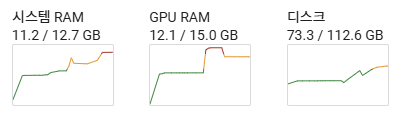

Qwen 7B를 L4로 파인튜닝한 후 llama.cpp로 gguf 변환한 경우<br>
main: quantize time = 129661.89 ms
main:    total time = 129661.89 ms
Unsloth: Conversion completed! Output location: /content/boazchung/deepseek-r1-medicalQA-Qwen/unsloth.Q4_K_M.gguf
Unsloth: Uploading GGUF to Huggingface Hub...
100%
 1/1 [00:40<00:00, 40.82s/it]
unsloth.Q4_K_M.gguf:
 4.69G/? [00:40<00:00, 430MB/s]
Unsloth: ##### The current model auto adds a BOS token.
Unsloth: ##### We removed it in GGUF's chat template for you.
Saved GGUF to https://huggingface.co/boazchung/deepseek-r1-medicalQA-Qwen

Qwen 7B L4 사용시<br>
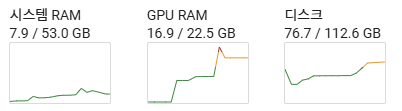

In [ ]:
# python llama.cpp/convert_hf_to_gguf.py SmolLM2-1.7B-Instruct --outfile ./SmolLM2.gguf
# llama-quantize SmolLM2.gguf SmolLM2.q8.gguf Q8_0 N

In [ ]:
# prompt: mount google drive

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
#@title Code for conversion to GGUF
def colab_quantize_to_gguf(save_directory, quantization_method = "q4_k_m"):
    from transformers.models.llama.modeling_llama import logger
    import os

    logger.warning_once(
        "Unsloth: `colab_quantize_to_gguf` is still in development mode.\n"\
        "If anything errors or breaks, please file a ticket on Github.\n"\
        "Also, if you used this successfully, please tell us on Discord!"
    )

    # From https://mlabonne.github.io/blog/posts/Quantize_Llama_2_models_using_ggml.html
    ALLOWED_QUANTS = \
    {
        "q2_k"   : "Uses Q4_K for the attention.vw and feed_forward.w2 tensors, Q2_K for the other tensors.",
        "q3_k_l" : "Uses Q5_K for the attention.wv, attention.wo, and feed_forward.w2 tensors, else Q3_K",
        "q3_k_m" : "Uses Q4_K for the attention.wv, attention.wo, and feed_forward.w2 tensors, else Q3_K",
        "q3_k_s" : "Uses Q3_K for all tensors",
        "q4_0"   : "Original quant method, 4-bit.",
        "q4_1"   : "Higher accuracy than q4_0 but not as high as q5_0. However has quicker inference than q5 models.",
        "q4_k_m" : "Uses Q6_K for half of the attention.wv and feed_forward.w2 tensors, else Q4_K",
        "q4_k_s" : "Uses Q4_K for all tensors",
        "q5_0"   : "Higher accuracy, higher resource usage and slower inference.",
        "q5_1"   : "Even higher accuracy, resource usage and slower inference.",
        "q5_k_m" : "Uses Q6_K for half of the attention.wv and feed_forward.w2 tensors, else Q5_K",
        "q5_k_s" : "Uses Q5_K for all tensors",
        "q6_k"   : "Uses Q8_K for all tensors",
        "q8_0"   : "Almost indistinguishable from float16. High resource use and slow. Not recommended for most users.",
    }

    if quantization_method not in ALLOWED_QUANTS.keys():
        error = f"Unsloth: Quant method = [{quantization_method}] not supported. Choose from below:\n"
        for key, value in ALLOWED_QUANTS.items():
            error += f"[{key}] => {value}\n"
        raise RuntimeError(error)
    pass

    print_info = \
        f"==((====))==  Unsloth: Conversion from QLoRA to GGUF information\n"\
        f"   \\\   /|    [0] Installing llama.cpp will take 3 minutes.\n"\
        f"O^O/ \_/ \\    [1] Converting HF to GUUF 16bits will take 3 minutes.\n"\
        f"\        /    [2] Converting GGUF 16bits to q4_k_m will take 20 minutes.\n"\
        f' "-____-"     In total, you will have to wait around 26 minutes.\n'
    print(print_info)

    if not os.path.exists("llama.cpp"):
        print("Unsloth: [0] Installing llama.cpp. This will take 3 minutes...")
        # !git clone https://github.com/ggerganov/llama.cpp
        # !cd llama.cpp && make clean && LLAMA_CUBLAS=1 make -j
        # !pip install gguf protobuf
    pass

    print("Unsloth: [1] Converting HF into GGUF 16bit. This will take 3 minutes...")
    !python llama.cpp/convert_hf_to_gguf.py {save_directory} \
        --outfile {save_directory}-unsloth.gguf \
        --outtype f16

    print("Unsloth: [2] Converting GGUF 16bit into q4_k_m. This will take 20 minutes...")
    final_location = f"./{save_directory}-{quantization_method}-unsloth.gguf"
    !./llama.cpp/llama-quantize ./{save_directory}-unsloth.gguf \
        {final_location} {quantization_method}

    print(f"Unsloth: Output location: {final_location}")
pass


In [ ]:
from unsloth import unsloth_save_model

# unsloth_save_model has the same args as model.save_pretrained
#unsloth_save_model(model, tokenizer, "output_model", push_to_hub = False, token = None)
colab_quantize_to_gguf("nanyaas/deepseek-r1-medicalQA-Qwen", quantization_method = "q4_k_m")

==((====))==  Unsloth: Conversion from QLoRA to GGUF information
   \\   /|    [0] Installing llama.cpp will take 3 minutes.
O^O/ \_/ \    [1] Converting HF to GUUF 16bits will take 3 minutes.
\        /    [2] Converting GGUF 16bits to q4_k_m will take 20 minutes.
 "-____-"     In total, you will have to wait around 26 minutes.

Unsloth: [1] Converting HF into GGUF 16bit. This will take 3 minutes...
INFO:hf-to-gguf:Loading model: deepseek-r1-medicalQA-Qwen
INFO:gguf.gguf_writer:gguf: This GGUF file is for Little Endian only
INFO:hf-to-gguf:Exporting model...
INFO:hf-to-gguf:gguf: loading model weight map from 'model.safetensors.index.json'
INFO:hf-to-gguf:gguf: loading model part 'model-00001-of-00004.safetensors'
INFO:hf-to-gguf:token_embd.weight,         torch.bfloat16 --> F16, shape = {3584, 152064}
INFO:hf-to-gguf:blk.0.attn_norm.weight,    torch.bfloat16 --> F32, shape = {3584}
INFO:hf-to-gguf:blk.0.ffn_down.weight,     torch.bfloat16 --> F16, shape = {18944, 3584}
INFO:hf-to-ggu

In [ ]:
! cp nanyaas/deepseek-r1-medicalQA-Qwen-q4_k_m-unsloth.gguf /content/drive/MyDrive/deepseek/medicalQA-gguf-Qwen-en/

==((====))==  Unsloth: Conversion from QLoRA to GGUF information
   \\   /|    [0] Installing llama.cpp will take 3 minutes.
O^O/ \_/ \    [1] Converting HF to GUUF 16bits will take 3 minutes.
\        /    [2] Converting GGUF 16bits to q4_k_m will take 20 minutes.
 "-____-"     In total, you will have to wait around 26 minutes.

Unsloth: [1] Converting HF into GGUF 16bit. This will take 3 minutes...
INFO:hf-to-gguf:Loading model: unsloth-medicalQA-en-model
INFO:gguf.gguf_writer:gguf: This GGUF file is for Little Endian only
INFO:hf-to-gguf:Exporting model...
INFO:hf-to-gguf:rope_freqs.weight,           torch.float32 --> F32, shape = {64}
INFO:hf-to-gguf:gguf: loading model weight map from 'model.safetensors.index.json'
INFO:hf-to-gguf:gguf: loading model part 'model-00001-of-00002.safetensors'
INFO:hf-to-gguf:token_embd.weight,           torch.float16 --> F16, shape = {4096, 128256}
INFO:hf-to-gguf:blk.0.attn_norm.weight,      torch.float16 --> F32, shape = {4096}
Traceback (most recent call last):
  File "/content/llama.cpp/convert_hf_to_gguf.py", line 5117, in <module>
    main()
  File "/content/llama.cpp/convert_hf_to_gguf.py", line 5111, in main
    model_instance.write()
  File "/content/llama.cpp/convert_hf_to_gguf.py", line 439, in write
    self.prepare_tensors()
  File "/content/llama.cpp/convert_hf_to_gguf.py", line 1704, in prepare_tensors
    super().prepare_tensors()
  File "/content/llama.cpp/convert_hf_to_gguf.py", line 298, in prepare_tensors
    for new_name, data_torch in (self.modify_tensors(data_torch, name, bid)):
                                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/llama.cpp/convert_hf_to_gguf.py", line 1672, in modify_tensors
    return [(self.map_tensor_name(name), data_torch)]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/llama.cpp/convert_hf_to_gguf.py", line 214, in map_tensor_name
    raise ValueError(f"Can not map tensor {name!r}")
ValueError: Can not map tensor 'model.layers.0.mlp.down_proj.base_layer.weight'
Unsloth: [2] Converting GGUF 16bit into q4_k_m. This will take 20 minutes...
/bin/bash: line 1: ./llama.cpp/llama-quantize: No such file or directory
Unsloth: Output location: .//content/drive/MyDrive/deepsek/unsloth-medicalQA-en-model-q4_k_m-unsloth.gguf

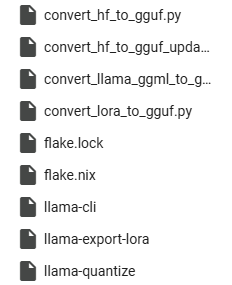

In [ ]:
# prompt: save the trained model

# import torch

# # Assuming 'trainer' is your SFTTrainer instance from the previous code
# # and 'model_lora' is your LoRA-wrapped model.

# # Save the LoRA model
trainer.save_model("./lora-model")

# # Optionally, save the entire model (larger file size)
# torch.save(model_lora.state_dict(), "./medicalQA-en-model.pt")


In [ ]:
!pip install numba

In [ ]:

from numba import cuda
device1 = cuda.get_current_device()
device1.reset()

In [ ]:
# prompt: clear cuda memory


with torch.no_grad():
    torch.cuda.empty_cache()


In [ ]:
#! cp   /content/medicalQA-en-model.pt                  /content/drive/MyDrive/deepsek

In [ ]:
#! cp  -r  /content/output_model                /content/drive/MyDrive/deepsek/unsloth-medicalQA-en-model

In [ ]:
#! tar -cvf lora-model.tar.gz ./lora-model

In [ ]:
# # prompt: load the  fine-tuned model by mergining the lora model and the unsloth/DeepSeek-R1-Distill-Llama-8B and perform inference

# import torch
# from peft import PeftModel, PeftConfig
# from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

# # Load the LoRA configuration
# config = PeftConfig.from_pretrained("./lora-model")

# # Quantization configuration with CPU offload
# bnb_config = BitsAndBytesConfig(
#     load_in_4bit=True,
#     bnb_4bit_use_double_quant=True,
#     bnb_4bit_quant_type="nf4",
#     bnb_4bit_compute_dtype=torch.float16,
#     llm_int8_enable_fp32_cpu_offload=True  # Enable CPU offload
# )

# # Load the base model and tokenizer
# model = AutoModelForCausalLM.from_pretrained(
#     "unsloth/DeepSeek-R1-Distill-Llama-8B",
#     quantization_config=bnb_config,  # Apply quantization config
#     device_map="auto",
#     token=os.environ.get("HF_TOKEN")
# )
# tokenizer = AutoTokenizer.from_pretrained("unsloth/DeepSeek-R1-Distill-Llama-8B", trust_remote_code=True)

# # Load the LoRA weights
# model = PeftModel.from_pretrained(model, "./lora-model")

# # Merge the LoRA weights with the base model
# model = model.merge_and_unload()

# # Move the model to the appropriate device
# model.to("cuda")

# # Example usage:
# question = """A 61-year-old woman with a long history of involuntary urine loss during activities like coughing or
#               sneezing but no leakage at night undergoes a gynecological exam and Q-tip test. Based on these findings,
#               what would cystometry most likely reveal about her residual volume and detrusor contractions?"""

# prompt_style = """Below is an instruction that describes a task, paired with an input that provides further context.
# Write a response that appropriately completes the request.
# Before answering, think carefully about the question and create a step-by-step chain of thoughts to ensure a logical and accurate response.

# ### Instruction:
# You are a medical expert with advanced knowledge in clinical reasoning, diagnostics, and treatment planning.
# Please answer the following medical question.

# ### Question:
# {}

# ### Response:
# <think>{}"""

# # Activate optimized inference mode for Unsloth
# FastLanguageModel.for_inference(model)  # This line is moved here

# inputs = tokenizer([prompt_style.format(question, "")], return_tensors="pt").to("cuda")
# outputs = model.generate(
#     input_ids=inputs.input_ids,
#     attention_mask=inputs.attention_mask,
#     max_new_tokens=1200,
#     use_cache=True,
# )
# response = tokenizer.batch_decode(outputs)
# print(response[0].split("### Response:")[1])


In [ ]:
import torch
from peft import PeftModel, PeftConfig
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from unsloth import FastLanguageModel

# Load the LoRA configuration
config = PeftConfig.from_pretrained("./lora-model")

# Quantization configuration with CPU offload
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    llm_int8_enable_fp32_cpu_offload=True  # Enable CPU offload
)

# Load the base model and tokenizer
model = AutoModelForCausalLM.from_pretrained(
    "unsloth/DeepSeek-R1-Distill-Llama-8B",
    quantization_config=bnb_config,  # Apply quantization config
    device_map="auto",
    token=os.environ.get("HF_TOKEN")
)
tokenizer = AutoTokenizer.from_pretrained("unsloth/DeepSeek-R1-Distill-Llama-8B", trust_remote_code=True)

# Load the LoRA weights
model = PeftModel.from_pretrained(model, "./lora-model")

# Merge the LoRA weights with the base model
model = model.merge_and_unload()

# Move the model to the appropriate device
model.to("cuda")

# Example usage:
question = """A 61-year-old woman with a long history of involuntary urine loss during activities like coughing or
              sneezing but no leakage at night undergoes a gynecological exam and Q-tip test. Based on these findings,
              what would cystometry most likely reveal about her residual volume and detrusor contractions?"""

prompt_style = """Below is an instruction that describes a task, paired with an input that provides further context.
Write a response that appropriately completes the request.
Before answering, think carefully about the question and create a step-by-step chain of thoughts to ensure a logical and accurate response.

### Instruction:
You are a medical expert with advanced knowledge in clinical reasoning, diagnostics, and treatment planning.
Please answer the following medical question.

### Question:
{}

### Response:
<think>{}"""

# Access the underlying LlamaModel and set max_seq_length
# Assuming FastLanguageModel has an attribute or method to access the underlying model
# Adjust this line based on the actual structure of FastLanguageModel
underlying_llama_model = model.model  # Or model._model, model.base_model, etc.

if underlying_llama_model is not None:
    underlying_llama_model.max_seq_length = 2048  # Set the desired max_seq_length

# Activate optimized inference mode for Unsloth
FastLanguageModel.for_inference(model)  # This line is moved here

inputs = tokenizer([prompt_style.format(question, "")], return_tensors="pt").to("cuda")
outputs = model.generate(
    input_ids=inputs.input_ids,
    attention_mask=inputs.attention_mask,
    max_new_tokens=1200,
    use_cache=True,
)
response = tokenizer.batch_decode(outputs)
print(response[0].split("### Response:")[1])

config.json:   0%|          | 0.00/959 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

model-00001-of-00004.safetensors:   0%|          | 0.00/4.98G [00:00<?, ?B/s]

model-00002-of-00004.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

model-00003-of-00004.safetensors:   0%|          | 0.00/4.92G [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/53.0k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/peft/tuners/lora/bnb.py:355: UserWarning: Merge lora module to 4-bit linear may get different generations due to rounding errors.
  warnings.warn(


AttributeError: 'LlamaForCausalLM' object has no attribute 'max_seq_length'

In [ ]:
import torch
from peft import PeftModel, PeftConfig
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, AutoConfig
from unsloth import FastLanguageModel

# Quantization configuration with CPU offload - optional but recommended
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,  # Use bfloat16 for better precision
    llm_int8_enable_fp32_cpu_offload=True,  # Enable CPU offload for memory efficiency
)

#model_name = "unsloth/DeepSeek-R1-Distill-Llama-8B"
model_name = "/content/drive/MyDrive/deepsek/unsloth-medicalQA-en-lora-model"
max_seq_length = 2048

# Arguments specific to FastLanguageModel
fast_model_args = {
    "max_seq_length": max_seq_length,
    "load_in_4bit": True,
   "quantization_config": bnb_config,
}

# Load the model, passing the appropriate arguments
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name,
    **fast_model_args,
    local_files_only=True,
)


# Prepare the model for inference
FastLanguageModel.for_inference(model)

# Move model to GPU if available
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

# Set to evaluation mode
model.eval()

# Example usage:
question = """A 61-year-old woman with a long history of involuntary urine loss during activities like coughing or
              sneezing but no leakage at night undergoes a gynecological exam and Q-tip test. Based on these findings,
              what would cystometry most likely reveal about her residual volume and detrusor contractions?"""

prompt_style = """Below is an instruction that describes a task, paired with an input that provides further context.
Write a response that appropriately completes the request.
Before answering, think carefully about the question and create a step-by-step chain of thoughts to ensure a logical and accurate response.

### Instruction:
You are a medical expert with advanced knowledge in clinical reasoning, diagnostics, and treatment planning.
Please answer the following medical question.

### Question:
{}

### Response:
<think>{}"""

# Access the underlying LlamaModel and set max_seq_length
# Assuming FastLanguageModel has an attribute or method to access the underlying model
# Adjust this line based on the actual structure of FastLanguageModel
#underlying_llama_model = model.model  # Or model._model, model.base_model, etc.

# if underlying_llama_model is not None:
#     underlying_llama_model.max_seq_length = 2048  # Set the desired max_seq_length

# # Activate optimized inference mode for Unsloth
# FastLanguageModel.for_inference(model)  # This line is moved here

# inputs = tokenizer([prompt_style.format(question, "")], return_tensors="pt").to("cuda")
# outputs = model.generate(
#     input_ids=inputs.input_ids,
#     attention_mask=inputs.attention_mask,
#     max_new_tokens=1200,
#     use_cache=True,
# )
# response = tokenizer.batch_decode(outputs)
# print(response[0].split("### Response:")[1])

==((====))==  Unsloth 2025.3.1: Fast Llama patching. Transformers: 4.48.3.
   \\   /|    GPU: NVIDIA L4. Max memory: 22.161 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.6.0+cu124. CUDA: 8.9. CUDA Toolkit: 12.4. Triton: 3.2.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.29.post3. FA2 = False]
 "-____-"     Free Apache license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Some weights of the model checkpoint at /content/drive/MyDrive/deepsek/unsloth-medicalQA-en-model were not used when initializing LlamaForCausalLM: ['model.layers.0.mlp.down_proj.base_layer.weight', 'model.layers.0.mlp.down_proj.base_layer.weight.absmax', 'model.layers.0.mlp.down_proj.base_layer.weight.nested_absmax', 'model.layers.0.mlp.down_proj.base_layer.weight.nested_quant_map', 'model.layers.0.mlp.down_proj.base_layer.weight.quant_map', 'model.layers.0.mlp.down_proj.base_layer.weight.quant_state.bitsandbytes__nf4', 'model.layers.0.mlp.down_proj.lora_A.default.weight', 'model.layers.0.mlp.down_proj.lora_B.default.weight', 'model.layers.0.mlp.gate_proj.base_layer.weight', 'model.layers.0.mlp.gate_proj.base_layer.weight.absmax', 'model.layers.0.mlp.gate_proj.base_layer.weight.nested_absmax', 'model.layers.0.mlp.gate_proj.base_layer.weight.nested_quant_map', 'model.layers.0.mlp.gate_proj.base_layer.weight.quant_map', 'model.layers.0.mlp.gate_proj.base_layer.weight.quant_state.bitsand

Model loaded successfully!

<think> нескénéohlohlüfigliüfénéistorüf.TableNameynes нескénéohlüféné неск�üfohlüfndata нескénéüfénéndataduitohl нескohltürynesüfüfénéSharper нескistorüflassian.bzogneaporeifersénéüf.bzénéüfénétheonüfüfénééné нескynesüfynesynesohlynesubat �ohlduitüfohl.Sn нескohlénéüfüfohlüfogneohlynesistor.Snapoogneüfigue �ubat зимüfynesénéndataynes �énéüfohlapoogneohl.Designerynesndataduitndataüfogneapoohlynesüfaporelassian �.Uiogneéné�ohlohl �ohlohlohlmaresohlubatduitynesリアohlφαρüfohlanoia442ohlénéüfohlüf�istorohlリアohl нескéné.Uiapoohlohlraj.UiリアazarohlohlaporeCanonicalüf.Uiüfineaogneüfogneüfduitohlohlohlohl.Uiartzndata�ohlraj.Sn�ohl.Snüfanoialassianrajohlohlohlльтineausraửapoohlduitohlapoüf нескohlisasndataynesduit.Uiльтohlrajisas.TableNameelerleaporeohllassiananoiaapo.Uiohlohlohlohlohlubatanoia지도ohlohlüfapondataüftheon.Uirajüfndata지도ogneohlipleCanonicallassianohlohlüfφαρльтohlndataohlohlohl442istorohlohlndataohlapoльтohlohlohlohlapolassianohlohlüfohlohlohl442�ohlapoubat

## Step 5 — Run model inference after fine-tuning

In [ ]:
%%time
question = """61세 여성이 기침이나 재채기 같은 활동 중에 발생하는 오랜 요실금 병력이 있으나,
밤에는 누출이 없습니다. 부인과 검사와 Q-tip 테스트를 시행하였습니다.
이러한 소견에 근거할 때, 방광내압검사는 잔뇨량과 배뇨근 수축에 대해 어떤 결과를 보여줄 가능성이 높을까요?"""

# Load the inference model using FastLanguageModel (Unsloth optimizes for speed)
FastLanguageModel.for_inference(model_lora)  # Unsloth has 2x faster inference!

# Tokenize the input question with a specific prompt format and move it to the GPU
inputs = tokenizer([prompt_style.format(question, "")], return_tensors="pt").to("cuda")

# Generate a response using LoRA fine-tuned model with specific parameters
outputs = model_lora.generate(
    input_ids=inputs.input_ids,          # Tokenized input IDs
    attention_mask=inputs.attention_mask, # Attention mask for padding handling
    max_new_tokens=1200,                  # Maximum length for generated response
    use_cache=True,                        # Enable cache for efficient generation
)

# Decode the generated response from tokenized format to readable text
response = tokenizer.batch_decode(outputs)

# Extract and print only the model's response part after "### Response:"
print(response[0].split("<think>")[-1].strip())

자, 61세 여성 환자가 있습니다.  오랫동안 요실금을 겪고 있는데, 기침이나 재채기와 같은 활동을 할 때 악화됩니다. 흥미로운 점은 밤에는 소변을 누르지 않아도 소변을 잘 보관한다는 것입니다.  이는 중요한 단서입니다.

먼저, 이러한 요실금의 원인이 무엇일지 생각해 봅시다. 요실금은 주로 요도 또는 방광의 기능이나 구조적 문제로 인해 발생할 수 있습니다.  잠깐만요,  요실금이 기침이나 재채기와 같은 특정 활동과 관련이 있다는 점을 고려하면,  방광이 비정상적으로 아래쪽으로 처져 있을 가능성이 있습니다. 이러한 방광 아래쪽 이동은 요도와 방광의 위치에 영향을 미치는 요골근의 기능 이상을 시사합니다.

이제, 방광 내압 검사(cystometric study)가 있습니다.  방광 내압을 측정하고 방광을 비우는 동안 방광을 유지하는 능력을 확인하는 검사입니다.  방광이 아래로 처져 있으면, 방광 내압이 상승할 수 있습니다.  이는 방광이 아래로 처지면 자체적 저항 때문에 더 높은 압력이 축적될 수 있기 때문입니다.

하지만 잠깐,  방광 내압이 높더라도, 이 환자의 경우 밤에는 누출이 없으므로,  방광 내압이 높더라도 배뇨 시 방광이 수축하는 능력이 문제가 아닌 것 같습니다.  방광 내압이 높더라도 배뇨근이 수축하는 데는 문제가 없다면,  배뇨 시 방광이 제대로 수축하는 것이 중요합니다.

따라서,  방광 내압이 높더라도 배뇨근이 수축하는 데는 문제가 없다면,  배뇨근 기능은 정상일 가능성이 높습니다.  방광 내압이 높더라도 배뇨근의 수축 기능이 정상이라면,  방광 내압과 배뇨근 기능 모두 정상일 수 있습니다.

아,  Q-tip test도 있습니다.  이는 방광 아래쪽이 처지면 방광의 움직임에 도움이 되는 요골근의 기능을 확인하는 데 사용됩니다.  Q-tip test 결과가 양성이라면,  요골근의 기능이 정상적으로 작용하여 방광이 아래쪽으로 처지더라도 배뇨 시 정상적으로 이동한다는 것을 의미합니다.

따라서,  Q-tip test 결과가 양성이고 배뇨근 기능이

In [ ]:
%%time
question = """59세 남성이 발열, 오한, 야간 발한, 전신 피로감을 호소하며 내원하였고,
대동맥판에서 12mm의 vegetation이 발견되었습니다. 혈액 배양 검사 결과는
gram-positive, catalase-negative, gamma-hemolytic cocci가 사슬 모양으로 관찰되었으며,
6.5% NaCl 배지에서는 자라지 않았습니다.
이 환자의 상태에 가장 관련 있는 선행 요인은 무엇일까요?"""


# Tokenize the input question with a specific prompt format and move it to the GPU
inputs = tokenizer([prompt_style.format(question, "")], return_tensors="pt").to("cuda")

# Generate a response using LoRA fine-tuned model with specific parameters
outputs = model_lora.generate(
    input_ids=inputs.input_ids,          # Tokenized input IDs
    attention_mask=inputs.attention_mask, # Attention mask for padding handling
    max_new_tokens=1200,                  # Maximum length for generated response
    use_cache=True,                        # Enable cache for efficient generation
)

# Decode the generated response from tokenized format to readable text
response = tokenizer.batch_decode(outputs)

# Extract and print only the model's response part after "### Response:"
print(response[0].split("<think>")[-1].strip())

알겠습니다, 무슨 일인지 살펴봅시다. 59세 남성이 발열, 오한, 야간 발한과 같은 전형적인 증상들을 보이고 있습니다.  꽤 심각해 보이고, 전신 피로감을 호소하고 있는데, 이는 단순한 감기와는 다릅니다.  더 심각한 질병일 가능성이 높습니다.

이제, 심장 판막, 특히 대동맥판에서 12mm 크기의 덩어리가 발견되었습니다.  이는 매우 심각한 징후입니다. 덩어리는 어떤 종류의 감염, 아마도 대동맥 판막의 감염일 가능성이 높습니다.

그리고, 혈액 배양 검사를 했는데, 그 결과는 gram-positive, catalase-negative, gamma-hemolytic cocci로 나타났습니다.  이는 특정 세균을 가리킵니다.  gram-positive, catalase-negative, gamma-hemolytic인 세균은 *Streptococcus viridans*와 *Enterococcus faecalis*와 같은 특정 세균을 생각하게 합니다.

하지만, 6.5% NaCl 배지에서 세균이 자라는 것을 보지 못했습니다.  이는 중요한 단서입니다. 일반적으로 *Enterococcus faecalis*는 6.5% NaCl 배지에서 자랍니다. 따라서, 이 세균은 아닙니다.

이제, *Streptococcus viridans*는 특히 고령자, 특히 심장 판막 문제가 있는 사람들에게서, 감염성 심내막염이나 대동맥 판막의 덩어리와 같은 합병증과 관련이 있습니다.

따라서, 이 모든 것을 종합해 볼 때, 환자의 상태는 *Streptococcus viridans*에 의한 감염성 심내막염과 매우 일치합니다.  이 세균은 심장 판막의 감염을 일으키는 것으로 알려져 있으며,  우리가 보고 있는 것과 같은 덩어리를 유발할 수 있습니다.

또한, 환자의 나이와 증상은 이 진단을 더욱 뒷받침합니다.  나이, 증상, 배양 결과를 종합해 볼 때, 감염성 심내막염이 가장 가능성이 높은 원인입니다.

따라서, 이 모든 것을 고려할 때, 이 환자의 상태는 *Streptococcus virida

In [ ]:
%%time
question = """61세 여성이 기침이나 재채기 같은 활동 중에 발생하는 오랜 요실금 병력이 있으나,
밤에는 누출이 없습니다. 부인과 검사와 Q-tip 테스트를 시행하였습니다.
이러한 소견에 근거할 때, 방광내압검사는 잔뇨량과 배뇨근 수축에 대해 어떤 결과를 보여줄 가능성이 높을까요?"""

# Load the inference model using FastLanguageModel (Unsloth optimizes for speed)
FastLanguageModel.for_inference(model)  # Unsloth has 2x faster inference!

# Tokenize the input question with a specific prompt format and move it to the GPU
inputs = tokenizer([prompt_style.format(question, "")], return_tensors="pt").to("cuda")

# Generate a response using LoRA fine-tuned model with specific parameters
outputs = model_lora.generate(
    input_ids=inputs.input_ids,          # Tokenized input IDs
    attention_mask=inputs.attention_mask, # Attention mask for padding handling
    max_new_tokens=1200,                  # Maximum length for generated response
    use_cache=True,                        # Enable cache for efficient generation
)

# Decode the generated response from tokenized format to readable text
response = tokenizer.batch_decode(outputs)

# Extract and print only the model's response part after "### Response:"
print(response[0].split("<think>")[-1].strip())

61세 여성 환자가 61세에 시작된 요실금을 호소하고 있습니다.  꽤 오래 지속되었으므로, 시간이 지남에 따라 방광 문제가 악화되었을 가능성이 있습니다.

현재 기침이나 재채기와 같은 활동 중에 요실금이 발생한다는 점이 눈에 띕니다.  방광이 압박될 때 요실금이 발생하는 경우가 많으므로, 방광이 정상보다 낮게 위치하고 있을 가능성이 높습니다.  이는 방광이 아래쪽으로 내려가서 요도 폐쇄될 때 발생하는 방광결석이나 방광낭종과 같은 질환을 시사합니다.

밤에는 요실금이 없다는 것은 요도 폐쇄가 발생하지 않는다는 것을 의미합니다.  이는 요도 폐쇄의 주요 원인인 방광결석이나 방광낭종과 같은 질환을 배제할 수 있게 합니다.  잠깐만요, 요실금이 밤에는 없지만 다른 시간에는 있으므로,  방광낭종일 가능성도 있습니다.  낭종은 밤에 방광을 눌러 요실금을 유발하지 않습니다.

부인과 검사와 Q-tip test를 시행했습니다.  이는 일반적으로 방광결석을 확인하기 위해 방광 내압을 측정하는 검사입니다.  방광결석은 방광 내압을 상승시킬 수 있으므로,  상승된 내압이 나타나면 방광결석이 있을 가능성이 높습니다.

만약 방광낭종이라면, Q-tip test에서 내압 상승은 나타나지 않을 것입니다.  내압 상승이 없다면, 방광낭종일 가능성이 높습니다.

자, 요실금이 활동 중에만 발생하고 밤에는 없다는 점을 고려하면, 방광낭종이 가능성이 높습니다.  방광낭종은 활동 중에만 요실금을 유발하는 경향이 있습니다.

그렇다면 방광내압검사에서 무엇을 볼 수 있을까요?  방광낭종은 방광을 누르지 않으므로, 일반적으로 방광 내압은 정상입니다.  정상적인 내압을 보이는 방광낭종은 방광을 눌러 요실금을 유발하지 않기 때문입니다.

요약하자면, 방광낭종일 가능성이 높으므로, 방광내압검사에서 정상적인 내압을 보일 가능성이 높습니다.  이는 방광내압검사에서 정상적인 내압을 보이는 방광낭종과 일치합니다.
</think>
방광낭종과 같은 질환의 경우, 방광내압검사(bulking pressure test)에

In [ ]:
import torch
from peft import PeftModel, PeftConfig
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, AutoConfig
from unsloth import FastLanguageModel

# Quantization configuration with CPU offload - optional but recommended
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,  # Use bfloat16 for better precision
    llm_int8_enable_fp32_cpu_offload=True,  # Enable CPU offload for memory efficiency
)

#model_name = "unsloth/DeepSeek-R1-Distill-Llama-8B"
model_name = "/content/drive/MyDrive/deepsek/unsloth-medicalQA-en-model"
max_seq_length = 2048

# Arguments specific to FastLanguageModel
fast_model_args = {
    "max_seq_length": max_seq_length,
    "load_in_4bit": True,
   "quantization_config": bnb_config,
}

# Load the model, passing the appropriate arguments
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name,
    **fast_model_args,
    local_files_only=True,
)

<ipython-input-1-9e35093eeec2>:4: UserWarning: WARNING: Unsloth should be imported before transformers, peft to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from unsloth import FastLanguageModel


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2025.3.3: Fast Llama patching. Transformers: 4.48.3.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.6.0+cu124. CUDA: 7.5. CUDA Toolkit: 12.4. Triton: 3.2.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.29.post3. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


In [ ]:
!pip install -q llama-cpp-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.7/66.7 MB 11.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.7 MB/s eta 0:00:00


In [ ]:
from transformers import AutoTokenizer
from llama_cpp import Llama
from huggingface_hub import hf_hub_download

# Hugging Face model ID and GGUF filename
model_id = "nanyaas/deepseek-r1-medicalQA"
gguf_filename = "unsloth.Q4_K_M.gguf"

# Load the tokenizer and model directly from Hugging Face
tokenizer = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True)
model = Llama(model_path=hf_hub_download(repo_id=model_id, filename=gguf_filename))

# Input prompt for inference
input_prompt = """A 61-year-old woman with a long history of involuntary urine loss during activities like coughing or sneezing
              but no leakage at night undergoes a gynecological exam and Q-tip test. Based on these findings,
              what would cystometry most likely reveal about her residual volume and detrusor contractions?"""

# Tokenize input and get a flat list of token IDs
input_ids = tokenizer(input_prompt, return_tensors="pt")["input_ids"][0].tolist() #get token IDs as list

# Perform inference using llama-cpp-python
outputs = model(input_ids, # Pass a list of token IDs
                max_tokens=1200, # Adjust according to expected output length
                stop=["### Instruction:", "### Response:", "<think>", "</think>"])

# Decode and print the result
result = tokenizer.decode(outputs['choices'][0]['text'])
print("Model Output:", result)

llama_model_loader: loaded meta data with 33 key-value pairs and 292 tensors from /root/.cache/huggingface/hub/models--boazchung--deepseek-r1-medicalQA/snapshots/3b9b556b78256009a183aaa083a9d24b82e2fe9f/unsloth.Q4_K_M.gguf (version GGUF V3 (latest))
llama_model_loader: Dumping metadata keys/values. Note: KV overrides do not apply in this output.
llama_model_loader: - kv   0:                       general.architecture str              = llama
llama_model_loader: - kv   1:                               general.type str              = model
llama_model_loader: - kv   2:                               general.name str              = Deepseek R1 Distill Llama 8b Unsloth ...
llama_model_loader: - kv   3:                       general.organization str              = Unsloth
llama_model_loader: - kv   4:                           general.finetune str              = unsloth-bnb-4bit
llama_model_loader: - kv   5:                           general.basename str              = deepseek-r1-distill-ll

TypeError: argument 'ids': Can't extract `str` to `Vec`

In [ ]:
! pip install -q langchain  langchain_community colab-xterm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 47.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.6/115.6 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 415.1/415.1 kB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 3.7 MB/s eta 0:00:00


In [ ]:
%load_ext colabxterm

ollama create deepseek -f /content/gdrive/MyDrive/deepseek/Modelfile.md

xterm 기동 후 1~3 수행<br>


1.   curl -fsSL https://ollama.com/install.sh | sh<br>
2. ollama serve &
3. ollama create deepsek_k_m -f /content/gdrive/MyDrive/deepseek/Modelfile.md
4. ollama list







In [ ]:
%xterm

Launching Xterm...

<IPython.core.display.Javascript object>